# analysis.cooccurrence

This notebook shows the coocurrence analyis employing the methodology stated by Veech et al. 

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
import random
from daforfer import DaforferDB
from scipy import stats
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()
# db.tov()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

## Codetection

We want to illustrate the huge number of codetections that had been obtained by our study. We compute codetection using a similar approach to the generation of the row-organism column-library matrix.


In [46]:
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

1. We merge virus and bacteria hits by **library**, generating quite a bulky dataframe.
2. We use that dataframe to build a network that we can represent in the article (it should look like a giant hair ball).
3. We save the graph, so we can load it with iGraph.

In [47]:
coexistence_list = pd.merge(
    virus_hits[['library', 'scientific_name']], 
    bacteria_hits[['library', 'scientific_name', 'pab_type']], 
    on='library', suffixes=['_virus', '_bacteria']
).drop_duplicates(['scientific_name_virus', 'scientific_name_bacteria'], keep='first')


In [48]:
M = nx.Graph()
for _, item in coexistence_list.iterrows():
    M.add_node(item.scientific_name_virus, kingdom='Virus')
    M.add_node(item.scientific_name_bacteria, kingdom='Bacteria')
    M.add_edge(item.scientific_name_virus, item.scientific_name_bacteria)

nx.write_graphml(M, "output/network.coexistance.virusbact-bylibrary.graphml")

In [49]:
M.number_of_edges() - 59

1837

Now we represent it.

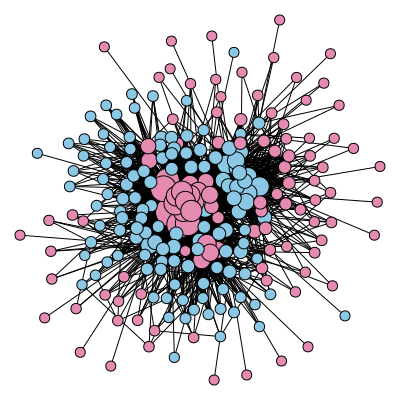

In [50]:
node_palette = {
    'host': "#73deac",
    'Virus': "#e58bb1",
    'Bacteria': "#8bc8e5",
}

g = ig.read("output/network.coexistance.virusbact-bylibrary.graphml", format='graphml')
node_colors = [node_palette[node['kingdom']] for node in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 20 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]

labels = [str(i) if d > 1000 else "" for i, (d, v) in enumerate(zip(degrees, g.vs))]
random.seed(5)
layout = g.layout("lgl")
ig.plot(
    g, layout=layout, target='figures/network.coexistance-bacteria-virus.svg',
    vertex_color=node_colors, edge_color='black', 
    vertex_size=normalized_sizes, vertex_label=labels, vertex_label_size=10,
    bbox=(400, 400)
)

The coexistance list might be an interesting piece of data for later analysis. We save it in both CSV and Spreadsheet format. 

In [51]:
db.save_dataframe(
    df=coexistence_list, table_name="D_virusBactCodetect",
    description="Each row of this table is a bacteria and virus detected in the same library"
)

Saved D_virusBactCodetect to db.2026-02-24


In [52]:
number_codetections = M.number_of_edges()
db.add_value("number_codetections", "Number of virus-bacteria library codetections", value=number_codetections, type='integer')
number_codetections

1896

## Coocurrence

We load the cooccurrence results, which were obtained through the R library ´cooccur´. The results of this library is a dataframe which contains some entries (not all of them) of the codetection list, together with their probabilities of
cooccurrence

In [53]:
coocurrence_results = pd.read_csv(
    "output/coocurrence.virusbact-bylibrary.csv", sep=',', index_col=0
)
coocurrence_results

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name
1,1,47,4,188,1,0.008,2.5,0.14612,0.98165,African eggplant yellowing virus,Cucumber mosaic virus RNA 3
2,1,88,4,134,2,0.006,1.8,0.76244,0.60696,African eggplant yellowing virus,Pelargonium zonate spot virus RNA 3
3,1,110,4,111,2,0.005,1.5,0.85388,0.47492,African eggplant yellowing virus,Rubus chlorotic mottle virus
4,1,125,4,106,2,0.005,1.4,0.87070,0.44522,African eggplant yellowing virus,Tobacco mild green mosaic virus
5,1,126,4,81,0,0.004,1.1,0.28046,1.00000,African eggplant yellowing virus,Tobacco mosaic virus
...,...,...,...,...,...,...,...,...,...,...,...
1101,204,246,26,12,5,0.003,1.0,0.99984,0.00176,Frigoribacterium sp. Leaf164,Pseudomonas oryzihabitans
1102,204,266,26,21,5,0.006,1.8,0.99470,0.02586,Frigoribacterium sp. Leaf164,Rhodococcoides fascians
1103,220,245,16,21,4,0.004,1.1,0.99724,0.01890,Methylobacterium sp. Leaf125,Pseudomonas lutea
1104,220,266,16,21,1,0.004,1.1,0.68832,0.69778,Methylobacterium sp. Leaf125,Rhodococcoides fascians


In the following block, we assign kingdom labels to `sp1` and `sp2` in each pair, so we can classify the cooccurrences between `virus-virus`, `bacteria-virus`, or `virus-bacteria`.

In [54]:
bacteria_names = bacteria_hits['scientific_name'].to_list()
virus_names = virus_hits['scientific_name'].to_list()
name_kingdom_map = {}
for b in bacteria_names:
    name_kingdom_map[b] = 'Bacteria'
for v in virus_names:
    name_kingdom_map[v] = 'Virus'
coocurrence_results['sp1_kingdom'] = coocurrence_results['sp1_name'].map(name_kingdom_map)
coocurrence_results['sp2_kingdom'] = coocurrence_results['sp2_name'].map(name_kingdom_map)
coocurrence_results = coocurrence_results.dropna(subset=['sp1_name', 'sp2_name'])

coocurrence_results

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom
1,1,47,4,188,1,0.008,2.5,0.14612,0.98165,African eggplant yellowing virus,Cucumber mosaic virus RNA 3,Virus,Virus
2,1,88,4,134,2,0.006,1.8,0.76244,0.60696,African eggplant yellowing virus,Pelargonium zonate spot virus RNA 3,Virus,Virus
3,1,110,4,111,2,0.005,1.5,0.85388,0.47492,African eggplant yellowing virus,Rubus chlorotic mottle virus,Virus,Virus
4,1,125,4,106,2,0.005,1.4,0.87070,0.44522,African eggplant yellowing virus,Tobacco mild green mosaic virus,Virus,Virus
5,1,126,4,81,0,0.004,1.1,0.28046,1.00000,African eggplant yellowing virus,Tobacco mosaic virus,Virus,Virus
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,204,246,26,12,5,0.003,1.0,0.99984,0.00176,Frigoribacterium sp. Leaf164,Pseudomonas oryzihabitans,Bacteria,Bacteria
1102,204,266,26,21,5,0.006,1.8,0.99470,0.02586,Frigoribacterium sp. Leaf164,Rhodococcoides fascians,Bacteria,Bacteria
1103,220,245,16,21,4,0.004,1.1,0.99724,0.01890,Methylobacterium sp. Leaf125,Pseudomonas lutea,Bacteria,Bacteria
1104,220,266,16,21,1,0.004,1.1,0.68832,0.69778,Methylobacterium sp. Leaf125,Rhodococcoides fascians,Bacteria,Bacteria


In [55]:
len(coocurrence_results.query('sp1_kingdom != sp2_kingdom'))

427

The following tables counts the number of positive coocurrences between kingdoms.

In [56]:
negative_cooccurrences = coocurrence_results.query('p_lt < 0.05').value_counts(['sp1_kingdom', 'sp2_kingdom']).reset_index()
positive_cooccurrences = coocurrence_results.query('p_gt < 0.05').value_counts(['sp1_kingdom', 'sp2_kingdom']).reset_index()
negative_cooccurrences['type'] = negative_cooccurrences.apply(lambda x: "-".join(sorted((x.sp1_kingdom, x.sp2_kingdom))), axis=1)
positive_cooccurrences['type'] = positive_cooccurrences.apply(lambda x: "-".join(sorted((x.sp1_kingdom, x.sp2_kingdom))), axis=1)
coocurrences_by_type = pd.merge(positive_cooccurrences[['type', 'count']], negative_cooccurrences[['type', 'count']], on='type', suffixes=['_positive', '_negative'], how='outer').fillna(0)
coocurrences_by_type['count_negative'] = coocurrences_by_type['count_negative'].astype(int)
coocurrences_by_type['count_positive'] = coocurrences_by_type['count_positive'].astype(int)

db.save_dataframe(coocurrences_by_type, "D_coocByType", description="Number and type of cooccurrences between bacteria/virus")
coocurrences_by_type

Saved D_coocByType to db.2026-02-24


,type,count_positive,count_negative
0,Bacteria-Bacteria,8,0
1,Bacteria-Virus,53,7
2,Virus-Virus,124,11


### Full coocurrence network

In [57]:
coocurrence_results = coocurrence_results.query('p_gt < 0.05 or p_lt < 0.05')
db.save_dataframe(
    df=coocurrence_results, table_name="D_cooccAll",
    description="Significative results (0.05) from cooccurrence analysis, including bacteria-bacteria and virus-virus cooccurrences"
)


Saved D_cooccAll to db.2026-02-24


In [58]:
M = nx.Graph()
for _, item in coocurrence_results.query('p_gt < 0.05').iterrows():
    M.add_edge(item.sp1_name, item.sp2_name, sign="positive")
for _, item in coocurrence_results.query('p_lt < 0.05').iterrows():
    M.add_edge(item.sp1_name, item.sp2_name, sign="negative")

nx.write_graphml(M, "output/network.coocurrence.virusbact-bylibrary.graphml")

In [59]:

for node, node_attributes in M.nodes(data=True):
    node_attributes['kingdom'] = name_kingdom_map[node]
    node_attributes['name'] = node

nodes_df = pd.DataFrame.from_records([node_attributes for _, node_attributes in M.nodes(data=True)])
nodes_df

,kingdom,name
0,Virus,Arabidopsis latent virus-1 RNA1
1,Virus,Turnip crinkle virus
2,Virus,Youcai mosaic virus
3,Virus,Barley yellow dwarf virus - GAV
4,Virus,Brassica yellows virus isolate
...,...,...
67,Bacteria,Pseudomonas lutea
68,Virus,Barley yellow dwarf virus - MAV
69,Virus,Barley yellow dwarf virus - PAV
70,Virus,Cowpea aphid-borne mosaic virus


In [60]:
nodes_df.value_counts(['kingdom'])

kingdom 
Virus       49
Bacteria    23
Name: count, dtype: int64

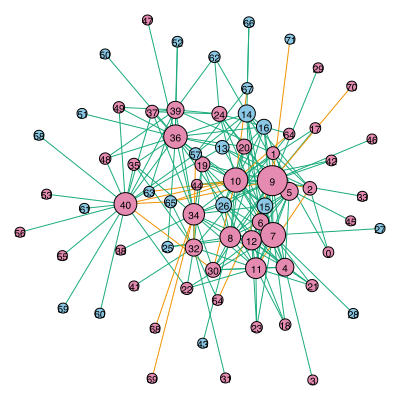

In [61]:
sign_palette = {
    'positive': "#1aab7c",
    'negative': "#f39200",
    
}
node_palette = {
    'host': "#73deac",
    'Virus': "#e58bb1",
    'Bacteria': "#8bc8e5",
}
name_kingdom_map['nan'] = 'Virus'
g = ig.read("output/network.coocurrence.virusbact-bylibrary.graphml", format='graphml')
edge_colors = [sign_palette[edge['sign']] for edge in g.es]
node_colors = [node_palette[name_kingdom_map[node['id']]] for node in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 20 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]

labels = [str(i) if d > 0 else "" for i, (d, v) in enumerate(zip(degrees, g.vs))]
random.seed(124)
layout = g.layout("lgl")
ig.plot(
    g, layout=layout, target='figures/network.coocurrence-bacteria-virus.svg',
    vertex_color=node_colors, edge_color=edge_colors, 

    vertex_size=normalized_sizes, vertex_label=labels, vertex_label_size=10,
    bbox=(400, 400)
)

### Virus-bacteria only network

To build the bacteria-virus only network, we keep only those edges where the kingdoms are different.

In [62]:
coocurrence_results = coocurrence_results.query('p_gt < 0.05 or p_lt < 0.05')
coocurrence_results = coocurrence_results.query('sp1_kingdom != sp2_kingdom')

db.save_dataframe(
    df=coocurrence_results, table_name="D_cooccBactVirus",
    description="Significative results (0.05) from cooccurrence analysis, including only virus-bacteria cooccurrences"
)
coocurrence_results

Saved D_cooccBactVirus to db.2026-02-24


,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom
145,21,196,27,14,4,0.004,1.3,0.99531,0.02828,Beet chlorosis virus,Duffyella gerundensis,Virus,Bacteria
146,21,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet chlorosis virus,Frigoribacterium sp. Leaf164,Virus,Bacteria
149,21,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet chlorosis virus,Pseudomonas oryzihabitans,Virus,Bacteria
150,21,266,27,21,5,0.006,1.9,0.99349,0.03026,Beet chlorosis virus,Rhodococcoides fascians,Virus,Bacteria
185,25,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,Virus,Bacteria
188,25,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet mild yellowing virus,Pseudomonas oryzihabitans,Virus,Bacteria
220,27,165,45,9,4,0.005,1.4,0.99506,0.03201,Beet western yellows virus,Agrobacterium tumefaciens,Virus,Bacteria
221,27,168,45,11,5,0.006,1.7,0.99782,0.01427,Beet western yellows virus,Arthrobacter sp. Leaf234,Virus,Bacteria
225,27,196,45,14,5,0.007,2.1,0.99017,0.04323,Beet western yellows virus,Duffyella gerundensis,Virus,Bacteria
229,27,246,45,12,6,0.006,1.8,0.99950,0.00386,Beet western yellows virus,Pseudomonas oryzihabitans,Virus,Bacteria


In [63]:
coocurrence_results_display_df = coocurrence_results[['sp1_name', 'sp2_name', 'p_lt', 'p_gt', 'obs_cooccur', 'exp_cooccur']].copy()
coocurrence_results_display_df['type'] = coocurrence_results_display_df['p_gt'].apply(lambda x: 'positive' if x < 0.05 else '')
coocurrence_results_display_df['type'] = coocurrence_results_display_df.apply(lambda x: 'negative' if x.p_lt < 0.05 else x.type, axis=1)
coocurrence_results_display_df

,sp1_name,sp2_name,p_lt,p_gt,obs_cooccur,exp_cooccur,type
145,Beet chlorosis virus,Duffyella gerundensis,0.99531,0.02828,4,1.3,positive
146,Beet chlorosis virus,Frigoribacterium sp. Leaf164,0.99920,0.00448,7,2.3,positive
149,Beet chlorosis virus,Pseudomonas oryzihabitans,0.99980,0.00211,5,1.1,positive
150,Beet chlorosis virus,Rhodococcoides fascians,0.99349,0.03026,5,1.9,positive
185,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,0.99920,0.00448,7,2.3,positive
188,Beet mild yellowing virus,Pseudomonas oryzihabitans,0.99980,0.00211,5,1.1,positive
220,Beet western yellows virus,Agrobacterium tumefaciens,0.99506,0.03201,4,1.4,positive
221,Beet western yellows virus,Arthrobacter sp. Leaf234,0.99782,0.01427,5,1.7,positive
225,Beet western yellows virus,Duffyella gerundensis,0.99017,0.04323,5,2.1,positive
229,Beet western yellows virus,Pseudomonas oryzihabitans,0.99950,0.00386,6,1.8,positive


In [64]:
M = nx.MultiGraph()
for _, item in coocurrence_results.query('p_gt < 0.05').iterrows():
    if item.sp1_kingdom != item.sp2_kingdom:
        M.add_edge(item.sp1_name, item.sp2_name, sign="positive")
for _, item in coocurrence_results.query('p_lt < 0.05').iterrows():
    if item.sp1_kingdom != item.sp2_kingdom:
        M.add_edge(item.sp1_name, item.sp2_name, sign="negative")

nx.write_graphml(M, "output/network.coocurrence.virusbact-bylibrary.trans.graphml")

In [65]:

for node, node_attributes in M.nodes(data=True):
    node_attributes['kingdom'] = name_kingdom_map[node]
    node_attributes['name'] = node

nodes_df = pd.DataFrame.from_records([node_attributes for _, node_attributes in M.nodes(data=True)])
nodes_df_counts_by_kingdom = nodes_df.value_counts(['kingdom'])
# db.add_value(
#     "number_PAB_cooccurrence", "Number of PABs involved in cooccurrence",
#     int(nodes_df_counts_by_kingdom.loc[('Bacteria',)]), # q000023 q000024
#     type='INTEGER'
# )
# db.add_value(
#     "number_virus_cooccurrence", "Number of virus involved in cooccurrence",
#     int(nodes_df_counts_by_kingdom.loc[('Virus',)]), # q000023 q000024
#     type='INTEGER'
# )
nodes_df_counts_by_kingdom

kingdom 
Bacteria    22
Virus       17
Name: count, dtype: int64

In [66]:
edges_df = pd.DataFrame.from_records([edge_attributes for _,_2, edge_attributes in M.edges(data=True)])
edges_df_bysign = edges_df.value_counts(['sign'])
edges_df_bysign

sign    
positive    53
negative     7
Name: count, dtype: int64

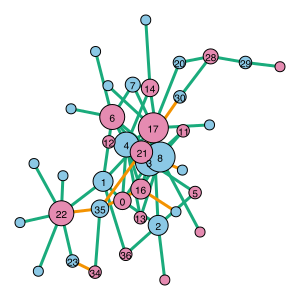

In [67]:
name_kingdom_map['nan'] = 'Virus'


g = ig.read("output/network.coocurrence.virusbact-bylibrary.trans.graphml", format='graphml')
edge_colors = [sign_palette[edge['sign']] for edge in g.es]
node_colors = [node_palette[name_kingdom_map[node['id']]] for node in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
degree_threshold = 2
normalized_sizes = [10 + 20 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
labels = [str(i) if d >= degree_threshold else "" for i, (d, v) in enumerate(zip(degrees, g.vs))]
random.seed(12)
layout = g.layout("lgl")
ig.plot(
    g, layout=layout, target='figures/network.coocurrence-bacteria-virus.trans.svg',
    vertex_color=node_colors, edge_color=edge_colors, 

    vertex_size=normalized_sizes, vertex_label=labels, vertex_label_size=10, edge_width=3,
    bbox=(300, 300)
)

In [68]:
M.number_of_edges()

60

In [69]:
M.number_of_nodes()

39

In [70]:
db.add_value(
    "cooccurrence_network_nodes", "Number of cooccurrence network nodes",
    int(M.number_of_nodes()), # q000023 q000024
    type='INTEGER'
)
db.add_value(
    "cooccurrence_network_edges", "Number of cooccurrence network edges",
    int(M.number_of_edges()), # q000023 q000024
    type='INTEGER'
)

In [71]:
network_node_labels = []
for i, (d, v) in enumerate(zip(degrees, g.vs)):
    if d >= degree_threshold:
        network_node_labels.append({"item": i, "degree": d, "name": v["id"]})
network_node_labels = pd.DataFrame.from_records(network_node_labels)

db.save_dataframe(
    df=network_node_labels, table_name="P_coocNetworkLabels",
    description="Labels of the coocccurence network figure, with their degree"
)
network_node_labels

Saved P_coocNetworkLabels to db.2026-02-24


,item,degree,name
0,0,4,Beet chlorosis virus
1,1,5,Duffyella gerundensis
2,2,5,Frigoribacterium sp. Leaf164
3,3,8,Pseudomonas oryzihabitans
4,4,7,Rhodococcoides fascians
5,5,2,Beet mild yellowing virus
6,6,7,Beet western yellows virus
7,7,3,Agrobacterium tumefaciens
8,8,9,Arthrobacter sp. Leaf234
9,11,2,Brassica yellows virus isolate


In [72]:


coocurrence_results['coocurrence_type'] = coocurrence_results.apply(lambda x: "-".join(sorted([x.sp1_kingdom, x.sp2_kingdom])), axis=1)
coocurrence_results

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom,coocurrence_type
145,21,196,27,14,4,0.004,1.3,0.99531,0.02828,Beet chlorosis virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus
146,21,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet chlorosis virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus
149,21,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet chlorosis virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus
150,21,266,27,21,5,0.006,1.9,0.99349,0.03026,Beet chlorosis virus,Rhodococcoides fascians,Virus,Bacteria,Bacteria-Virus
185,25,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus
188,25,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet mild yellowing virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus
220,27,165,45,9,4,0.005,1.4,0.99506,0.03201,Beet western yellows virus,Agrobacterium tumefaciens,Virus,Bacteria,Bacteria-Virus
221,27,168,45,11,5,0.006,1.7,0.99782,0.01427,Beet western yellows virus,Arthrobacter sp. Leaf234,Virus,Bacteria,Bacteria-Virus
225,27,196,45,14,5,0.007,2.1,0.99017,0.04323,Beet western yellows virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus
229,27,246,45,12,6,0.006,1.8,0.99950,0.00386,Beet western yellows virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus


### Virus-bacteria cooccurrence network properties

We use the same kind of calculation that we will use later for the properties of bipartite host-virus/bacteria networks. 

#### Write down adjacency matrix

In [73]:
coocurrence_results

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom,coocurrence_type
145,21,196,27,14,4,0.004,1.3,0.99531,0.02828,Beet chlorosis virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus
146,21,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet chlorosis virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus
149,21,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet chlorosis virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus
150,21,266,27,21,5,0.006,1.9,0.99349,0.03026,Beet chlorosis virus,Rhodococcoides fascians,Virus,Bacteria,Bacteria-Virus
185,25,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus
188,25,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet mild yellowing virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus
220,27,165,45,9,4,0.005,1.4,0.99506,0.03201,Beet western yellows virus,Agrobacterium tumefaciens,Virus,Bacteria,Bacteria-Virus
221,27,168,45,11,5,0.006,1.7,0.99782,0.01427,Beet western yellows virus,Arthrobacter sp. Leaf234,Virus,Bacteria,Bacteria-Virus
225,27,196,45,14,5,0.007,2.1,0.99017,0.04323,Beet western yellows virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus
229,27,246,45,12,6,0.006,1.8,0.99950,0.00386,Beet western yellows virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus


In [74]:
def assign_sign(x):
    if x['p_lt'] < 0.05:
        return -1
    elif x['p_gt'] < 0.05:
        return 1
coocurrence_results['cooccurrence_type'] = coocurrence_results.apply(assign_sign, axis=1)

In [75]:
coocurrence_results[:10]

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom,coocurrence_type,cooccurrence_type
145,21,196,27,14,4,0.004,1.3,0.99531,0.02828,Beet chlorosis virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus,1
146,21,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet chlorosis virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus,1
149,21,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet chlorosis virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus,1
150,21,266,27,21,5,0.006,1.9,0.99349,0.03026,Beet chlorosis virus,Rhodococcoides fascians,Virus,Bacteria,Bacteria-Virus,1
185,25,204,27,26,7,0.008,2.3,0.99920,0.00448,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,Virus,Bacteria,Bacteria-Virus,1
188,25,246,27,12,5,0.004,1.1,0.99980,0.00211,Beet mild yellowing virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus,1
220,27,165,45,9,4,0.005,1.4,0.99506,0.03201,Beet western yellows virus,Agrobacterium tumefaciens,Virus,Bacteria,Bacteria-Virus,1
221,27,168,45,11,5,0.006,1.7,0.99782,0.01427,Beet western yellows virus,Arthrobacter sp. Leaf234,Virus,Bacteria,Bacteria-Virus,1
225,27,196,45,14,5,0.007,2.1,0.99017,0.04323,Beet western yellows virus,Duffyella gerundensis,Virus,Bacteria,Bacteria-Virus,1
229,27,246,45,12,6,0.006,1.8,0.99950,0.00386,Beet western yellows virus,Pseudomonas oryzihabitans,Virus,Bacteria,Bacteria-Virus,1


In [76]:
coocurrence_results.value_counts('cooccurrence_type')

cooccurrence_type
 1    53
-1     7
Name: count, dtype: int64

In [77]:
coocurrence_results['foo'] = (coocurrence_results['cooccurrence_type'] != 0.0).astype(int)
coocurrence_results_pvt =  coocurrence_results.query('cooccurrence_type != 0').query('coocurrence_type == "Bacteria-Virus"').pivot(
    index='sp1_name', columns='sp2_name', values='foo'
).fillna(0)

coocurrence_results_pvt.to_csv("scratch/adjmat.cooccurrence-virus-bacteria.csv", sep=";")
coocurrence_results_pvt

sp2_name,Agrobacterium tumefaciens,Arthrobacter sp. Leaf234,Bradyrhizobium elkanii,Curtobacterium flaccumfaciens,Duffyella gerundensis,Frigoribacterium sp. Leaf164,Frigoribacterium sp. Leaf186,Methylobacterium sp. Leaf125,Modestobacter sp. Leaf380,Pantoea ananatis,...,Pseudomonas punonensis,Pseudomonas sp. Leaf127,Rhizobium sp. Leaf311,Rhizobium sp. NFR03,Rhodococcoides fascians,Sanguibacter sp. Leaf3,Sphingomonas sp. Leaf20,Sphingomonas sp. Leaf208,Xanthomonas campestris,Xylophilus sp. Leaf220
sp1_name,,,,,,,,,,,,,,,,,,,,,
Beet chlorosis virus,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Beet mild yellowing virus,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Beet western yellows virus,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
Brassica yellows virus isolate,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cucumber mosaic virus RNA 3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Maize dwarf mosaic virus,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Parietaria mottle virus RNA 3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
Pelargonium zonate spot virus RNA 3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Pepper mild mottle virus,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## Calculate bipartite network properties

Use the script `compute-cooccurrence-network-properties.R`

#### Process bipartite results

This includes a null file and and observation file.

In [78]:
null = pd.read_csv("scratch/bipartite.cooccurrence-virus-bacteria.null.csv")
observed = pd.read_csv("scratch/bipartite.cooccurrence-virus-bacteria.observed.csv")
observed

,Metric,Value
0,connectance,0.160428
1,modularity,0.456667
2,NODF,30.634488


#### Plots

Connectance plot

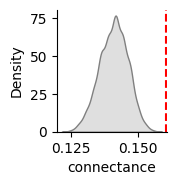

In [79]:
g = sns.displot(data=null, x='connectance', kind='kde', aspect=1.0, fill=True, height=2.0, color='gray')
m : float = float(observed.set_index('Metric').loc['connectance', 'Value']) # pyright: ignore[reportArgumentType]
g.ax.axvline(m, linestyle='--', color='red')

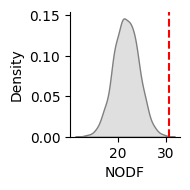

In [80]:
g = sns.displot(data=null, x='NODF', kind='kde', aspect=1.0, fill=True, height=2.0, color='gray')
g.ax.axvline(observed.set_index('Metric').loc['NODF', 'Value'], linestyle='--', color='red') # pyright: ignore[reportArgumentType]

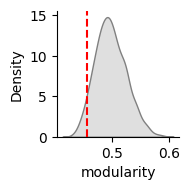

In [81]:
g = sns.displot(data=null, x='modularity', kind='kde', aspect=1.0, fill=True, height=2.0, color='gray')
g.ax.axvline(observed.set_index('Metric').loc['modularity'].Value, linestyle='--', color='red') # pyright: ignore[reportArgumentType]

#### Compute Z-scores

We compute the Z-score against the null model substracting the mean of the null model and dividing the standard deviation.

In [82]:
Z_scores = pd.merge(
    pd.merge(
        null.reset_index().melt(id_vars=['index'], value_vars=['modularity', 'connectance', 'NODF']).groupby('variable', as_index=False)['value'].mean().rename(columns={'value': 'null_mean'}), # pyright: ignore[reportCallIssue]
        null.reset_index().melt(id_vars=['index'], value_vars=['modularity', 'connectance', 'NODF']).groupby('variable', as_index=False)['value'].std().rename(columns={'value': 'null_std'}),  # pyright: ignore[reportCallIssue]
        on='variable'
    ),
    observed, left_on='variable', right_on='Metric'
)
Z_scores['Z-score'] = (Z_scores['Value'] - Z_scores['null_mean']) / Z_scores['null_std']
Z_scores

,variable,null_mean,null_std,Metric,Value,Z-score
0,NODF,21.696625,2.583075,NODF,30.634488,3.460165
1,connectance,0.140912,0.005209,connectance,0.160428,3.746578
2,modularity,0.497948,0.026628,modularity,0.456667,-1.550263


#### Compute t-test

We use the 1-sample t-test below to compute the p-value of our observation being the mean of the null model.

In [83]:
ttest = []
for metric in ['NODF', 'connectance', 'modularity']:
    v = observed.set_index('Metric').loc[metric].Value
    t_stat, p_val = stats.ttest_1samp(null[metric].values, v)
    ttest.append({"Metric": metric, "p-value": p_val, "ttest-stat": t_stat})

ttest_df = pd.DataFrame.from_records(ttest)
ttest_df

,Metric,p-value,ttest-stat
0,NODF,0.000000e+00,-109.420009
1,connectance,0.000000e+00,-118.477189
2,modularity,4.354560e-268,49.023616


### Save

In [84]:
network_statistics = pd.merge(Z_scores, ttest_df, on='Metric')
db.save_dataframe(
    df=network_statistics, table_name="T_coocBipStats",
    description="Cooccurrence network connectance, Modularity and Nestedness (NODF) analyzed using null model r2d-derived Z-scores and t-test 1 sample"
)
network_statistics

Saved T_coocBipStats to db.2026-02-24


,variable,null_mean,null_std,Metric,Value,Z-score,p-value,ttest-stat
0,NODF,21.696625,2.583075,NODF,30.634488,3.460165,0.000000e+00,-109.420009
1,connectance,0.140912,0.005209,connectance,0.160428,3.746578,0.000000e+00,-118.477189
2,modularity,0.497948,0.026628,modularity,0.456667,-1.550263,4.354560e-268,49.023616


In [85]:
db.close()